# Results Visualization

## This notebook can display all previously saved figures and generates an additional model performance summary figure

### *Imports*

In [1]:
from IPython.display import Image
import pandas as pd
import matplotlib.pyplot as plt

### *Correlation heatmap from raw dataset*

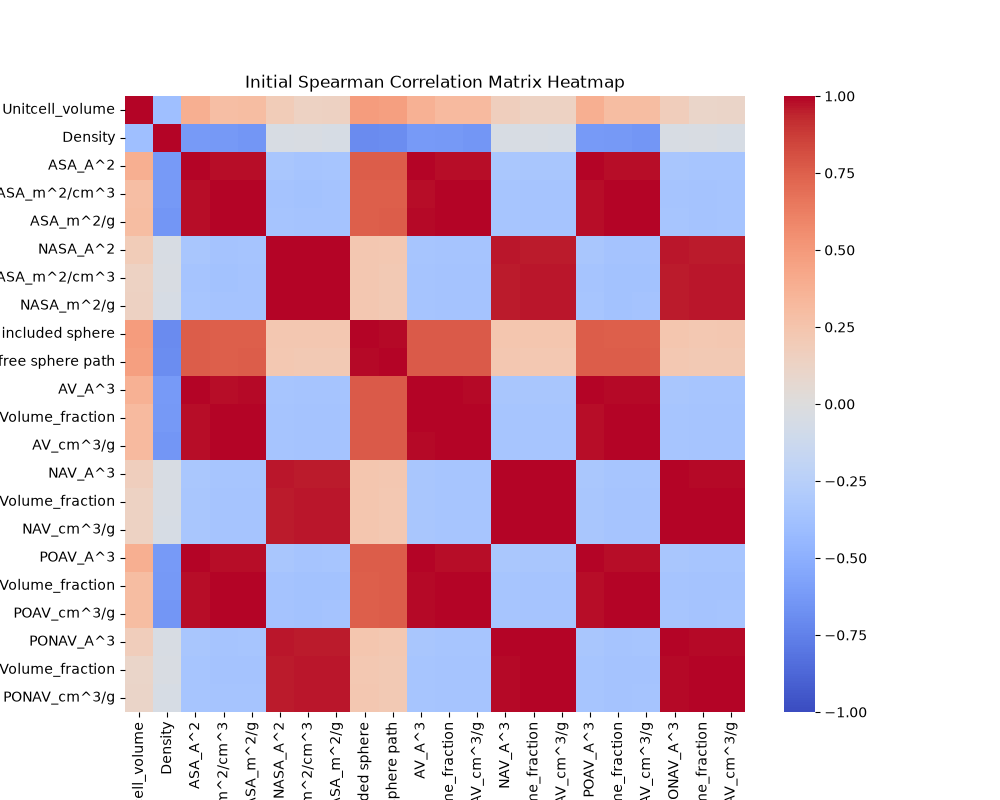

In [2]:
Image(filename='figures/initial_corr_heatmap.png')

### *Correlation heatmap after removing redundant features*

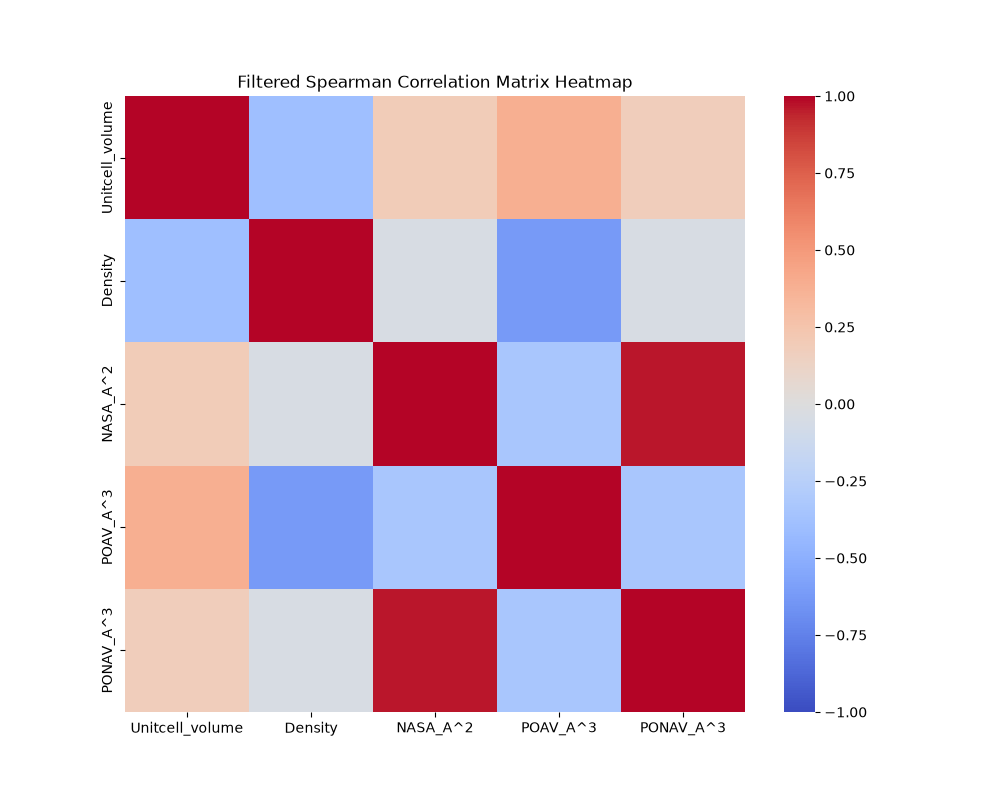

In [3]:
Image(filename='figures/reduced_corr_heatmap.png')

### *Histogram with KDE for the target property*

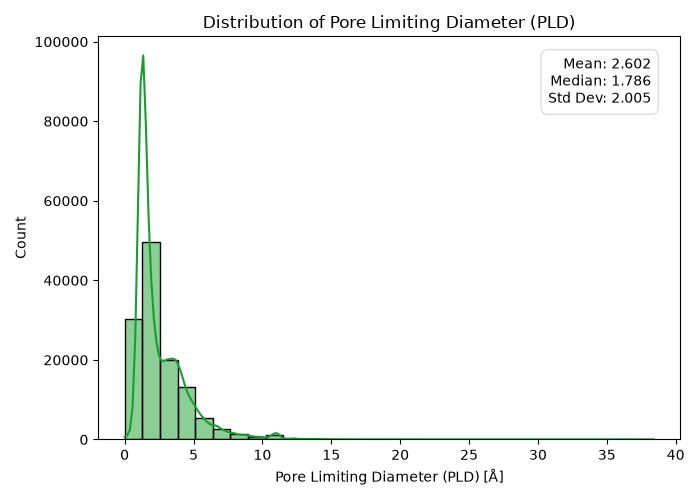

In [4]:
Image(filename='figures/PLD_distribution.png')

### *Correlations of the remaining features with the property being predicted*

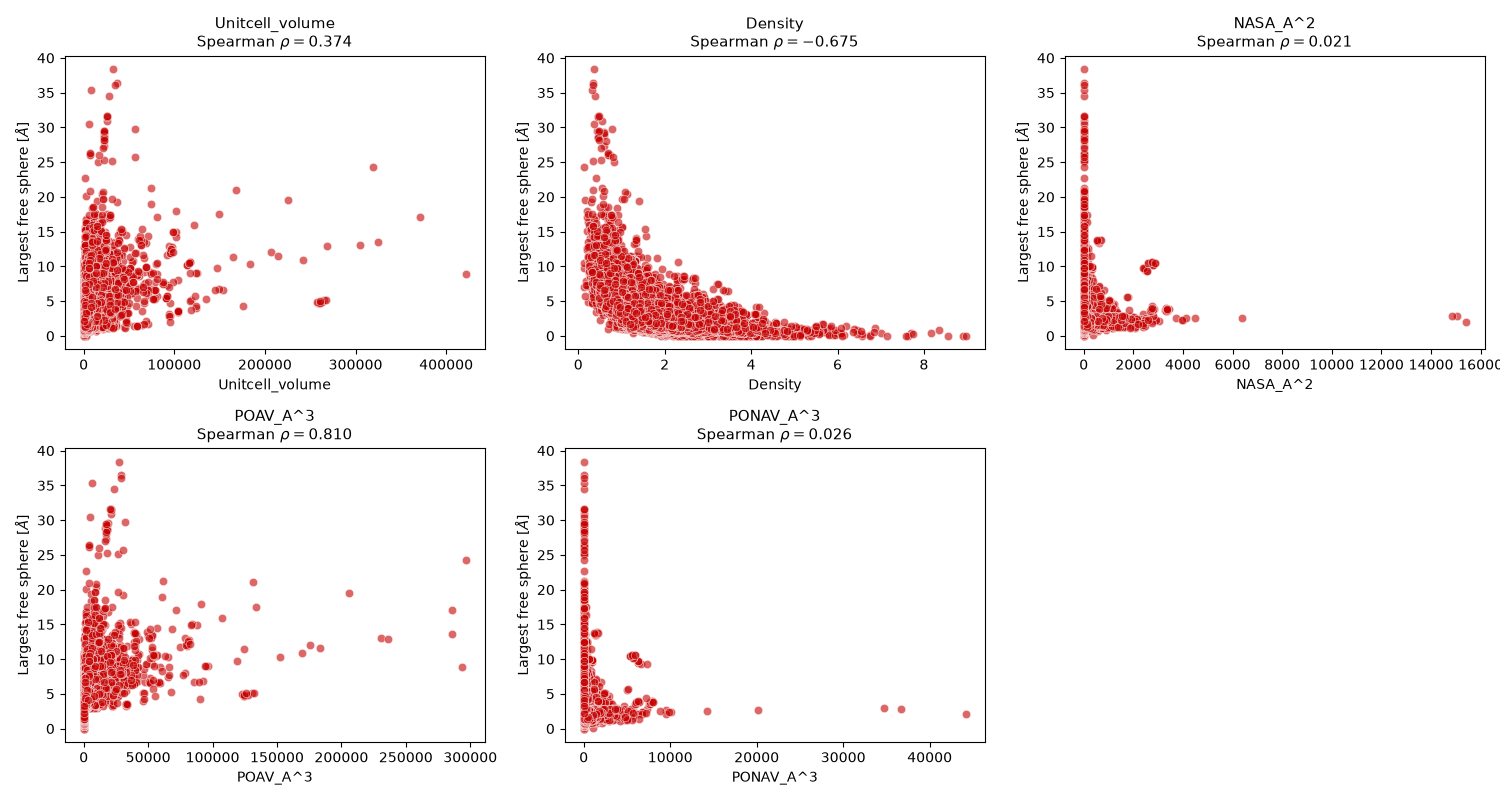

In [5]:
Image(filename='figures/target_feature_correlations.png')

### *Parity plot of the predicted property (from a single GKF fold)*

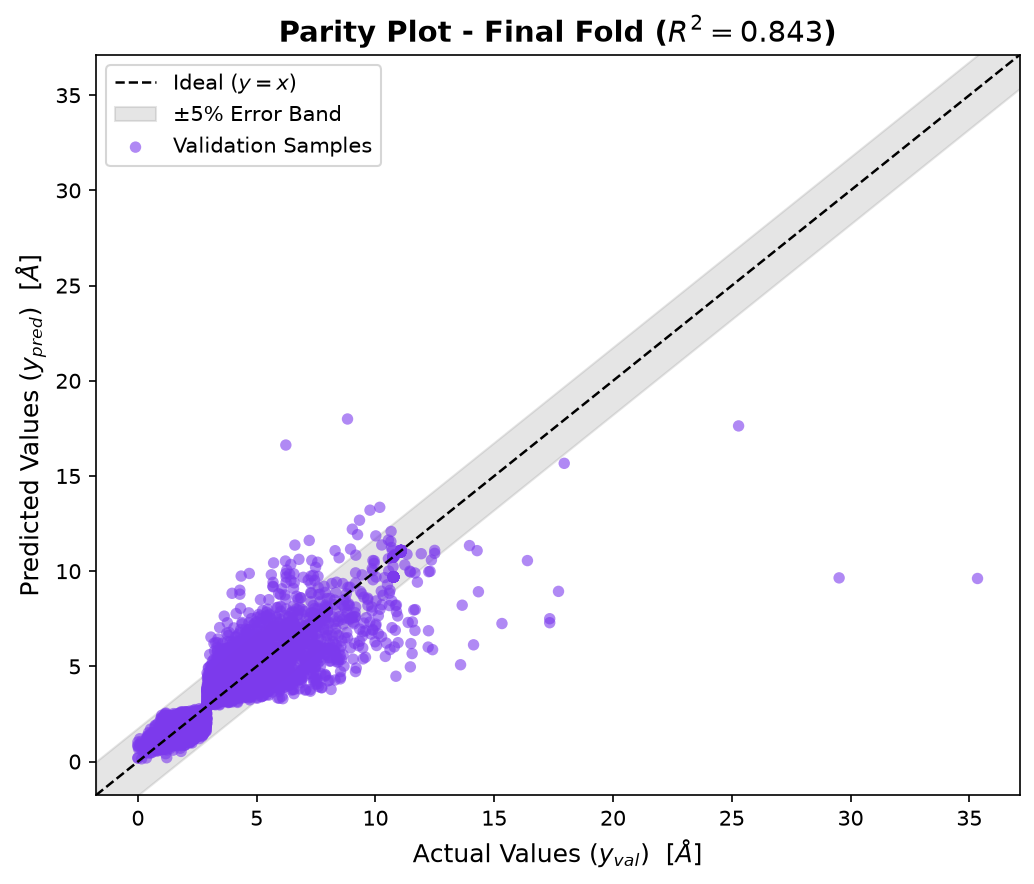

In [6]:
Image(filename='figures/parity_plot.png')

### *Residuals plot of the predicted property (from a single GKF fold)*

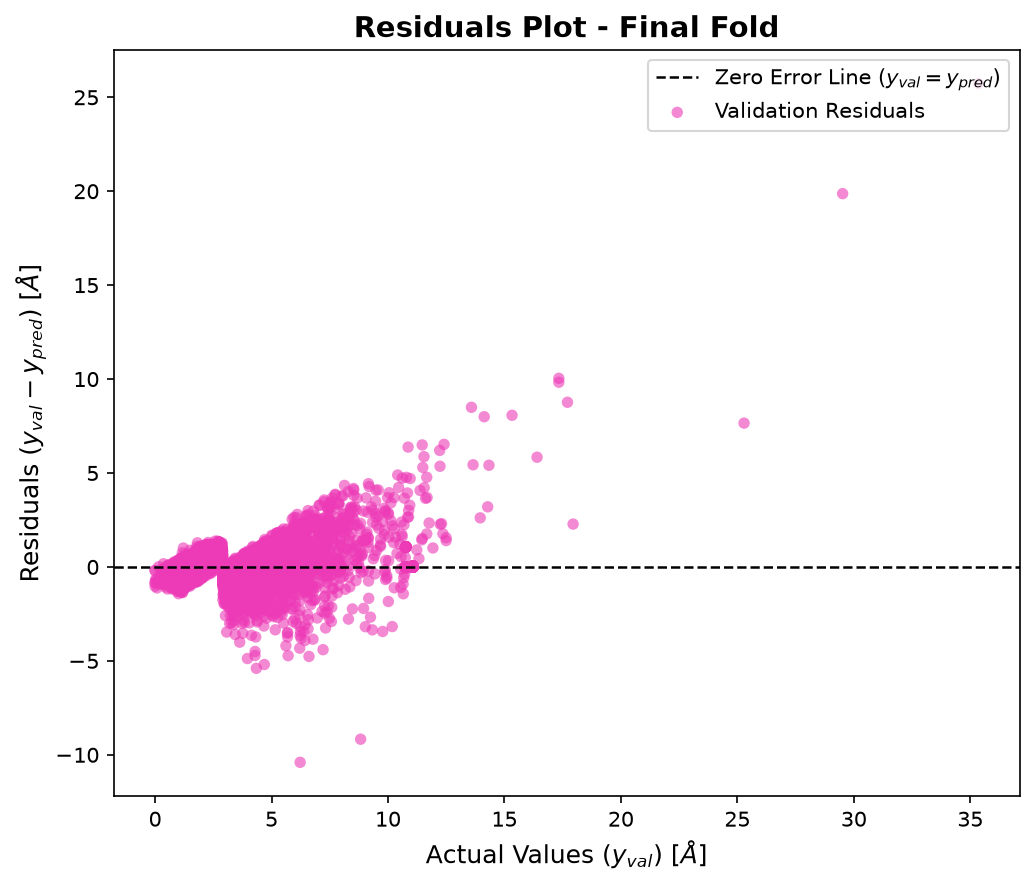

In [7]:
Image(filename='figures/residuals_plot.png')

### *Feature importances for the trained RF model*

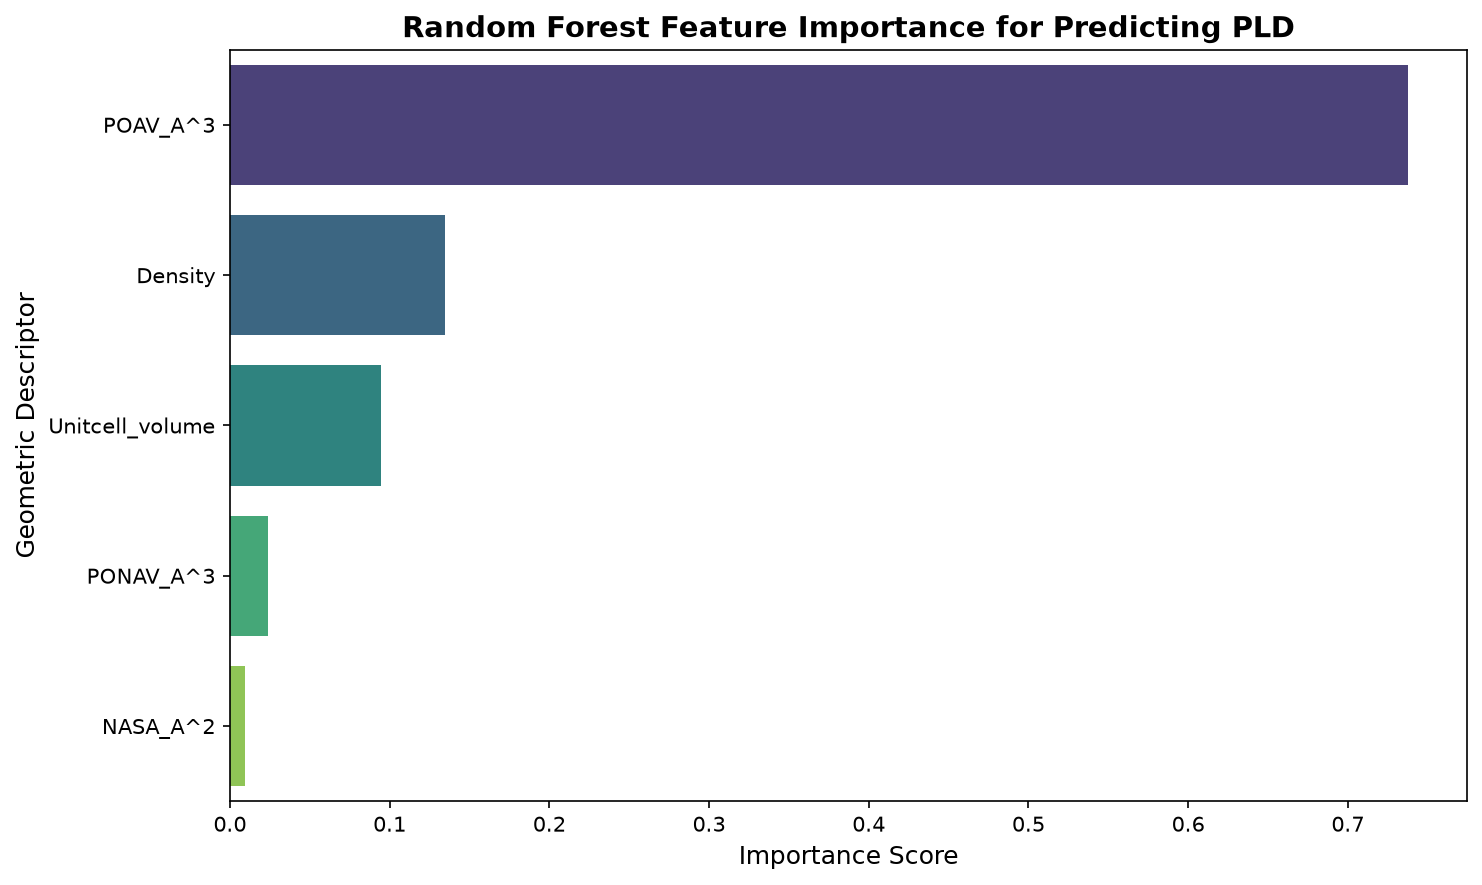

In [8]:
Image(filename='figures/feature_importances.png')

### *Display results by fold*

*generate new figure of test and train R^2, MAE, RMSE plotted per fold*

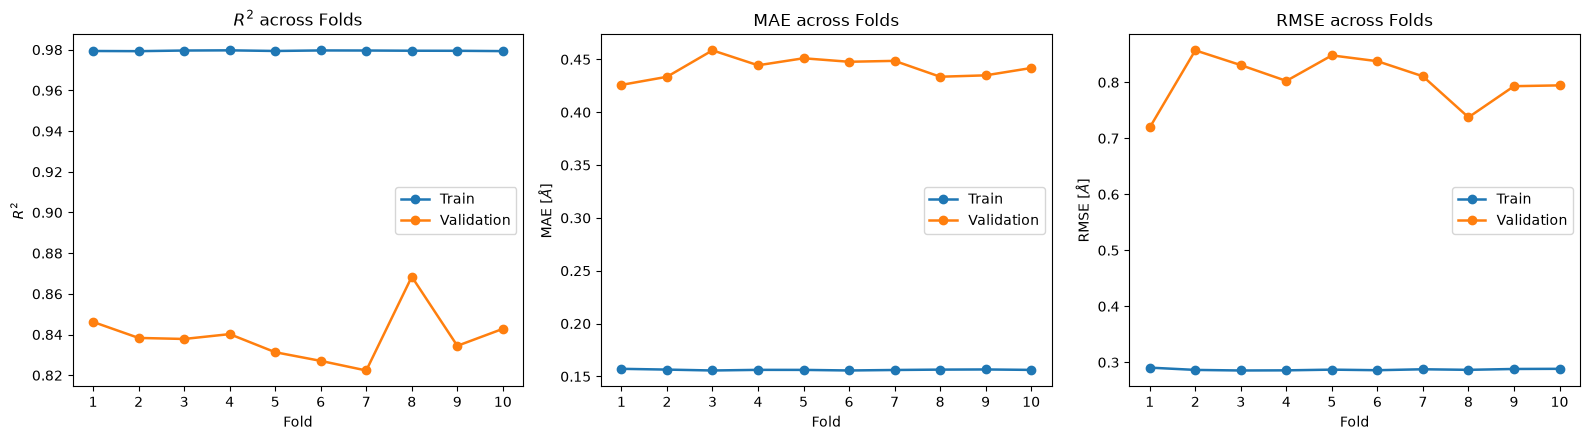

In [9]:
# import the R^2 and error results stored per fold
df_fold_results = pd.read_csv("data/results_metrics.csv")

# Create subplot figure for side-by-side plots
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Define title, y label, train col, val col
metrics = [
    (r"$R^2$", r"$R^2$", "R2_Train", "R2_Val"),
    ("MAE", "MAE [$\AA$]", "MAE_Train", "MAE_Val"),
    ("RMSE", "RMSE [$\AA$]", "RMSE_Train", "RMSE_Val"),
]

for ax, (title, ylabel, train_col, val_col) in zip(axes, metrics): # iterate through axes/plots
    
    # Plot training metric series
    ax.plot(
        df_fold_results["Fold"],
        df_fold_results[train_col],
        marker="o",
        linestyle="-",
        linewidth=1.8,
        label="Train",
    )

    # Plot test metric series
    ax.plot(
        df_fold_results["Fold"],
        df_fold_results[val_col],
        marker="o",
        linestyle="-",
        linewidth=1.8,
        label="Validation",
    )

    # Set style and labels
    ax.set_title(f"{title} across Folds", fontsize=12)
    ax.set_xlabel("Fold", fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xticks(df_fold_results["Fold"])
    ax.grid(False)
    ax.legend()

plt.tight_layout()

# Save the figure
plt.savefig("figures/fold_metrics.png")